# 04 — Method Comparison: Popularity vs LocalAgg vs PPR

Avalia e compara sistematicamente os três métodos de previsão de cestas:
- **Popularity**: baseline sem contexto (frequência global de produtos)
- **LocalAgg**: agregação de arestas de confiança a partir dos itens observados
- **PPR**: Personalized PageRank sobre o grafo de confiança

Todas as métricas são **condicionais ao grafo**: produtos do teste ausentes do grafo de co-ocorrência
(29,2% dos produtos únicos) são excluídos do numerador e denominador. O recall condicional é
aproximadamente 41% mais alto que o recall verdadeiro — ver seção 2 para correção.

## 0. Setup

In [1]:
import sys, os, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RESULTS_PATH     = '../outputs/results/experiment_results_merged.parquet'
HIT_RATES_PATH   = '../outputs/results/product_hit_rates_merged.parquet'
PARAMS_PATH      = '../outputs/results/params_merged.json'
TEST_DATA        = '../data/processed/test.parquet'
ALPHA_SWEEP_BASE = '../outputs/results/alpha_sweep'

METHOD_LABELS  = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER   = ['popularity', 'local_agg', 'ppr']
METHOD_COLORS  = {'popularity': 'tab:gray', 'local_agg': 'tab:orange', 'ppr': 'tab:blue'}
N_OBS_FRACTIONS = [0.25, 0.5, 0.75]
FRAC_LABELS     = {0.25: '25%', 0.5: '50%', 0.75: '75%'}
K_VALUES        = [5, 10, 20]

## 1. Carregamento dos Dados

In [2]:
with open(PARAMS_PATH) as f:
    params = json.load(f)
print('Parâmetros do experimento:')
for k, v in params.items():
    print(f'  {k}: {v}')

results = pd.read_parquet(RESULTS_PATH)
print(f'\nShape: {results.shape}')
print(f'Métodos:  {sorted(results["method"].unique())}')
print(f'n_obs:    {sorted(results["n_obs"].unique())}')
print(f'k:        {sorted(results["k"].unique())}')
print(f'Cestas:   {results["basket_id"].nunique():,}')
results.head()

Parâmetros do experimento:
  seed: 42
  min_cooccurrence: 2
  min_basket_size: 2
  max_basket_size: None
  n_obs: ['0.25', '0.5', '0.75']
  k_values: [5, 10, 20]
  n_repetitions: 10
  alpha: 0.85
  n_shards: 5
  n_workers: 4
  protocol: fraction
  n_hidden: None
  min_in_graph_basket_size: 4

Shape: (9013680, 7)
Métodos:  ['local_agg', 'popularity', 'ppr']
n_obs:    [np.float64(0.25), np.float64(0.5), np.float64(0.75)]
k:        [np.int64(5), np.int64(10), np.int64(20)]
Cestas:   33,384


,basket_id,n_obs,method,k,repetition,precision,recall
0,5,0.25,popularity,5,0,0.0,0.0
1,5,0.25,popularity,10,0,0.0,0.0
2,5,0.25,popularity,20,0,0.0,0.0
3,5,0.25,local_agg,5,0,0.0,0.0
4,5,0.25,local_agg,10,0,0.0,0.0


In [3]:
# Agregação por cesta: média sobre repetições → F1
per_basket_all = (
    results
    .groupby(['basket_id', 'n_obs', 'method', 'k'])[['precision', 'recall']]
    .mean()
    .reset_index()
)
denom = per_basket_all['precision'] + per_basket_all['recall']
per_basket_all['f1'] = np.where(
    denom == 0, 0.0,
    2 * per_basket_all['precision'] * per_basket_all['recall'] / denom.replace(0, np.nan),
)
print(f'per_basket_all shape: {per_basket_all.shape}')

per_basket_all shape: (901368, 7)


## 2. Cobertura do Grafo (contexto das métricas)

In [4]:
from src.graph_builder import load_graph
G = load_graph('../outputs/graphs')
graph_products = set(G.nodes())

test_df = pd.read_parquet(TEST_DATA, columns=['basket_id', 'product_idx'])
all_test_products = set(test_df['product_idx'].unique())
in_graph = all_test_products & graph_products
GRAPH_COV = len(in_graph) / len(all_test_products)

print(f'Produtos únicos no teste:        {len(all_test_products):,}')
print(f'Presentes no grafo (avaliados):  {len(in_graph):,} ({100*GRAPH_COV:.1f}%)')
print(f'Ausentes do grafo (excluídos):   {len(all_test_products)-len(in_graph):,} ({100*(1-GRAPH_COV):.1f}%)')
print(f'\nFator de correção para recall verdadeiro: ×{GRAPH_COV:.3f}')
print(f'  Recall condicional × {GRAPH_COV:.3f} = recall verdadeiro sobre a cesta completa')

Produtos únicos no teste:        37,745
Presentes no grafo (avaliados):  26,710 (70.8%)
Ausentes do grafo (excluídos):   11,035 (29.2%)

Fator de correção para recall verdadeiro: ×0.708
  Recall condicional × 0.708 = recall verdadeiro sobre a cesta completa


## 3. Tabela Resumo: Precision, Recall e F1

Média das métricas sobre todas as cestas para cada combinação de método × k × n_obs.
F1 = 0 quando P=R=0 (cestas sem nenhum hit contam com zero, não são excluídas).

In [5]:
grand = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
)
grand['method_label'] = grand['method'].map(METHOD_LABELS)
grand['n_obs_label']  = grand['n_obs'].map(FRAC_LABELS)

full_index = pd.MultiIndex.from_product(
    [[FRAC_LABELS[f] for f in N_OBS_FRACTIONS], [METHOD_LABELS[m] for m in METHOD_ORDER]],
    names=['n_obs', 'method'],
)

for metric in ['precision', 'recall', 'f1']:
    pivot = grand.pivot_table(
        index=['n_obs_label', 'method_label'], columns='k', values=metric,
    ).reindex(full_index)
    print(f'\n{metric.upper()}@k')
    display(pivot)
    if metric == 'recall':
        print(f'  → Recall verdadeiro = recall condicional × {GRAPH_COV:.3f} (corrige ausência do grafo)')
        display((pivot * GRAPH_COV).round(4).rename_axis(None, axis=1))


PRECISION@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0614  0.0437  0.0319
      LocalAgg    0.0974  0.0739  0.0547
      PPR         0.0731  0.0523  0.0379
50%   Popularity  0.0418  0.0294  0.0215
      LocalAgg    0.0684  0.0522  0.0388
      PPR         0.0498  0.0355  0.0256
75%   Popularity  0.0199  0.0138  0.0102
      LocalAgg    0.0332  0.0251  0.0186
      PPR         0.0237  0.0167  0.0121


RECALL@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0319  0.0450  0.0633
      LocalAgg    0.0560  0.0828  0.1172
      PPR         0.0397  0.0563  0.0800
50%   Popularity  0.0323  0.0451  0.0636
      LocalAgg    0.0600  0.0897  0.1285
      PPR         0.0403  0.0573  0.0810
75%   Popularity  0.0327  0.0452  0.0642
      LocalAgg    0.0630  0.0934  0.1337
      PPR         0.0410  0.0578  0.0817

  → Recall verdadeiro = recall condicional × 0.708 (corrige ausência do grafo)


5       10      20
n_obs method                            
25%   Popularity  0.0226  0.0318  0.0448
      LocalAgg    0.0396  0.0586  0.0829
      PPR         0.0281  0.0398  0.0566
50%   Popularity  0.0229  0.0319  0.0450
      LocalAgg    0.0425  0.0635  0.0909
      PPR         0.0285  0.0405  0.0573
75%   Popularity  0.0231  0.0320  0.0454
      LocalAgg    0.0446  0.0661  0.0946
      PPR         0.0290  0.0409  0.0578


F1@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0369  0.0385  0.0372
      LocalAgg    0.0625  0.0678  0.0655
      PPR         0.0451  0.0469  0.0449
50%   Popularity  0.0318  0.0311  0.0286
      LocalAgg    0.0556  0.0576  0.0533
      PPR         0.0386  0.0380  0.0346
75%   Popularity  0.0212  0.0187  0.0161
      LocalAgg    0.0374  0.0351  0.0300
      PPR         0.0257  0.0228  0.0193

## 4. Comparação Visual: Recall@k e F1@k por Método

/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)


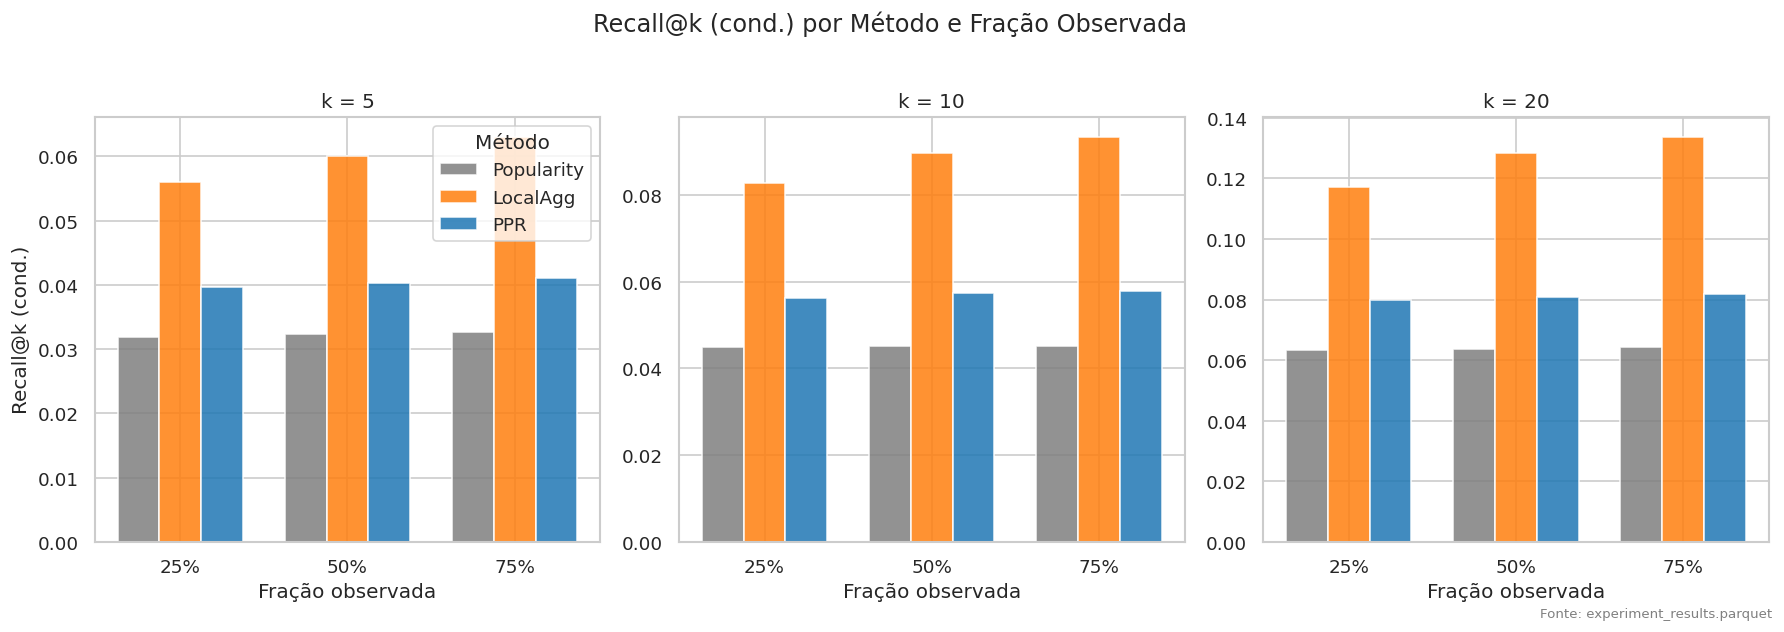

/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
/tmp/ipykernel_36574/818798017.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)


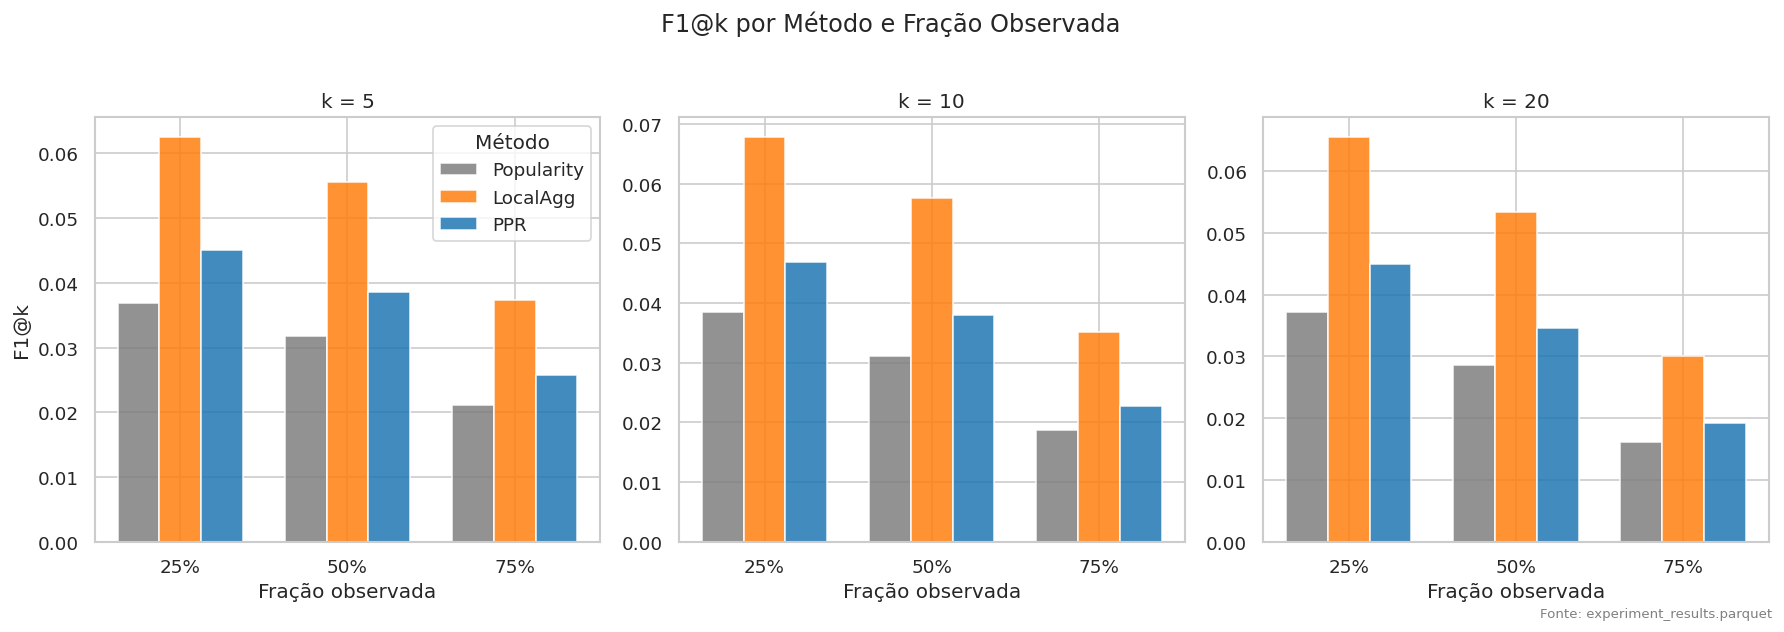

In [ ]:
# Recall@k: one panel per k, methods as bars, n_obs as hue
for metric, metric_label in [('recall', 'Recall@k '), ('f1', 'F1@k')]:
    fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
    for ax, k_val in zip(axes, K_VALUES):
        sub = grand[grand['k'] == k_val].copy()
        sub['n_obs_label'] = pd.Categorical(sub['n_obs_label'], [FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
        sub['method_label'] = pd.Categorical(sub['method_label'], [METHOD_LABELS[m] for m in METHOD_ORDER])
        pivot = sub.pivot_table(index='n_obs_label', columns='method_label', values=metric)
        pivot = pivot[[METHOD_LABELS[m] for m in METHOD_ORDER]]
        x = np.arange(len(N_OBS_FRACTIONS))
        width = 0.25
        for i, method in enumerate(METHOD_ORDER):
            label = METHOD_LABELS[method]
            bars = ax.bar(
                x + (i - 1) * width, pivot[label],
                width=width, label=label, color=METHOD_COLORS[method], alpha=0.85,
            )
        ax.set_xticks(x)
        ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
        ax.set_xlabel('Fração observada')
        ax.set_ylabel(metric_label if ax == axes[0] else '')
        ax.set_title(f'k = {k_val}')
        if ax == axes[0]:
            ax.legend(title='Método')
    fig.suptitle(f'{metric_label} por Método e Fração Observada', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Recall Estratificado por Tamanho de Cesta

Cestas muito pequenas (2–3 itens) têm alta variância — um único hit muda o recall de 0 para 0,33–0,5.
Cestas maiores revelam com mais clareza as diferenças reais entre métodos.

In [ ]:
basket_sizes = (
    test_df.groupby('basket_id')['product_idx']
    .count()
    .rename('basket_size')
    .reset_index()
)
# The experiment enumerates baskets by sorted basket_id order (groupby default),
# so the positional index is the basket_id used in results.
basket_sizes['basket_id'] = range(len(basket_sizes))

size_bins   = [1, 3, 5, 10, 20, int(basket_sizes['basket_size'].max()) + 1]
size_labels = ['2–3', '4–5', '6–10', '11–20', '21+']
basket_sizes['size_group'] = pd.cut(
    basket_sizes['basket_size'], bins=size_bins, labels=size_labels, right=True,
)

print('Cestas por grupo de tamanho:')
print(basket_sizes['size_group'].value_counts().sort_index())

k_ref = 10
strat = (
    per_basket_all[per_basket_all['k'] == k_ref]
    .merge(basket_sizes[['basket_id', 'size_group']], on='basket_id')
    .groupby(['size_group', 'n_obs', 'method'], observed=True)['recall']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, len(N_OBS_FRACTIONS), figsize=(5*len(N_OBS_FRACTIONS), 5), sharey=True)
for ax, n_obs_val in zip(axes, N_OBS_FRACTIONS):
    sub = strat[(strat['n_obs'] == n_obs_val)]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('size_group')
        ax.plot(
            grp['size_group'].astype(str), grp['recall'],
            marker='o', label=METHOD_LABELS[method], color=METHOD_COLORS[method],
        )
    ax.set_xlabel('Grupo de tamanho')
    ax.set_ylabel(f'Recall@{k_ref} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'n_obs = {FRAC_LABELS[n_obs_val]}')
    if ax == axes[0]:
        ax.legend(title='Método')

fig.suptitle(f'Recall@{k_ref} (cond.) por Grupo de Tamanho de Cesta', y=1.02)
plt.tight_layout()
plt.show()

## 6. Significância Estatística — Teste de Wilcoxon

Teste emparelhado por cesta (H₁: método A > método B). Com ~33 mil cestas, o poder estatístico
é extremo — qualquer Δ > 0.001 resulta em p ≈ 0. O que importa operacionalmente é `mean_Δrecall`
(tamanho de efeito), não o p-valor.

In [8]:
pairs = [
    ('local_agg', 'popularity', 'LocalAgg > Popularity'),
    ('ppr',       'popularity', 'PPR > Popularity'),
    ('local_agg', 'ppr',        'LocalAgg > PPR'),
]

rows = []
for n_obs_val in sorted(results['n_obs'].unique()):
    sub_n = per_basket_all[per_basket_all['n_obs'] == n_obs_val]
    for k_val in K_VALUES:
        wide = (
            sub_n[sub_n['k'] == k_val]
            .pivot(index='basket_id', columns='method', values='recall')
            .dropna()
        )
        for m1, m2, label in pairs:
            d = wide[m1] - wide[m2]
            nonzero = d[d != 0]
            pval = wilcoxon(nonzero, alternative='greater').pvalue if len(nonzero) >= 20 else float('nan')
            rows.append({
                'n_obs': FRAC_LABELS[n_obs_val], 'k': k_val, 'comparison': label,
                'mean_Δrecall': round(d.mean(), 5),
                'pct_baskets_Δ>0': round((d > 0).mean(), 3),
                'p_value': round(pval, 6),
            })

sig_df = pd.DataFrame(rows)
n_obs_order = [FRAC_LABELS[f] for f in N_OBS_FRACTIONS]

print('=== Tamanho de efeito (mean_Δrecall) — primário ===\n')
for _, _, label in pairs:
    sub = sig_df[sig_df['comparison'] == label]
    print(f'{label}:')
    display(
        sub.pivot_table(index='n_obs', columns='k', values='mean_Δrecall')
        .reindex(n_obs_order).round(5)
    )
    display(
        sub.pivot_table(index='n_obs', columns='k', values='pct_baskets_Δ>0')
        .reindex(n_obs_order).round(3).rename_axis('fração de cestas com Δ>0', axis=0)
    )
    display(
        sub.pivot_table(index='n_obs', columns='k', values='p_value')
        .reindex(n_obs_order).round(6).rename_axis('p-value (Wilcoxon)', axis=0)
    )
    print()

=== Tamanho de efeito (mean_Δrecall) — primário ===

LocalAgg > Popularity:


k,5,10,20
n_obs,,,
25%,0.02416,0.03778,0.05395
50%,0.02769,0.04455,0.06489
75%,0.03032,0.04824,0.06952


k,5,10,20
fração de cestas com Δ>0,,,
25%,0.441,0.540,0.617
50%,0.342,0.445,0.542
75%,0.231,0.327,0.424


k,5,10,20
p-value (Wilcoxon),,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0



PPR > Popularity:


...

k,5,10,20
p-value (Wilcoxon),,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0



LocalAgg > PPR:


k,5,10,20
n_obs,,,
25%,0.01634,0.02646,0.03724
50%,0.01966,0.03238,0.04752
75%,0.02198,0.03568,0.05203


k,5,10,20
fração de cestas com Δ>0,,,
25%,0.379,0.488,0.562
50%,0.290,0.396,0.492
75%,0.184,0.271,0.362


k,5,10,20
p-value (Wilcoxon),,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


## 7. Sensibilidade do PPR ao Parâmetro α (Alpha Sweep)

O α controla o trade-off entre personalização local (seeds observados) e propagação global no grafo.
Alpha sweep sobre α ∈ {0.30, 0.50, 0.70, 0.85} com LocalAgg e Popularity como referências fixas.

**Pergunta:** A superioridade do LocalAgg sobre o PPR é artefato de α = 0.85?

In [9]:
ALPHA_VALUES = [0.30, 0.50, 0.70, 0.85]

sweep_dfs = []
for alpha_dir in sorted(os.listdir(ALPHA_SWEEP_BASE)):
    path = os.path.join(ALPHA_SWEEP_BASE, alpha_dir, 'experiment_results_merged.parquet')
    df = pd.read_parquet(path)
    df['alpha'] = float(alpha_dir.replace('alpha_', '').replace('_', '.'))
    sweep_dfs.append(df)
sweep = pd.concat(sweep_dfs, ignore_index=True)

sweep_pb = (
    sweep.groupby(['basket_id', 'n_obs', 'method', 'k', 'alpha'])[['precision', 'recall']]
    .mean().reset_index()
)
denom_sw = sweep_pb['precision'] + sweep_pb['recall']
sweep_pb['f1'] = np.where(
    denom_sw == 0, 0.0,
    2 * sweep_pb['precision'] * sweep_pb['recall'] / denom_sw.replace(0, np.nan),
)
sweep_agg = (
    sweep_pb.groupby(['n_obs', 'method', 'k', 'alpha'])[['precision', 'recall', 'f1']]
    .mean().round(4).reset_index()
)
print(f'Alpha values: {sorted(sweep["alpha"].unique())}')
print(f'Shape: {sweep_agg.shape}')

Alpha values: [np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.85)]
Shape: (108, 7)


In [ ]:
# Plot: PPR Recall@k vs alpha, com LocalAgg e Popularity como referências (n_obs=0.5)
ref_n_obs = 0.5
ref_alpha = 0.85

ppr_curve = sweep_agg[(sweep_agg['method'] == 'ppr') & (sweep_agg['n_obs'] == ref_n_obs)]
ref_la    = sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]
ref_pop   = sweep_agg[(sweep_agg['method'] == 'popularity') & (sweep_agg['n_obs'] == ref_n_obs) & (sweep_agg['alpha'] == ref_alpha)]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5*len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = ppr_curve[ppr_curve['k'] == k_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['recall'], marker='o', markersize=8, color='tab:blue', label='PPR (α sweep)')
    la_val  = ref_la[ref_la['k'] == k_val]['recall'].values[0]
    pop_val = ref_pop[ref_pop['k'] == k_val]['recall'].values[0]
    ax.axhline(la_val,  color='tab:orange', linestyle='--', linewidth=1.5, label=f'LocalAgg = {la_val:.4f}')
    ax.axhline(pop_val, color='tab:gray',   linestyle=':',  linewidth=1.5, label=f'Popularity = {pop_val:.4f}')
    ax.set_xlabel('α (damping factor)')
    ax.set_ylabel(f'Recall@{k_val} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'k = {k_val}')
    ax.set_xticks(ALPHA_VALUES)
    ax.legend(fontsize=8)
fig.suptitle(f'PPR Recall@k vs α  —  n_obs = {FRAC_LABELS[ref_n_obs]}', y=1.03)
plt.tight_layout()
plt.show()

# Gap LocalAgg − PPR vs alpha
k_gap = 10
la_vals  = sweep_agg[(sweep_agg['method'] == 'local_agg') & (sweep_agg['k'] == k_gap)].set_index(['n_obs', 'alpha'])['recall']
ppr_vals = sweep_agg[(sweep_agg['method'] == 'ppr')       & (sweep_agg['k'] == k_gap)].set_index(['n_obs', 'alpha'])['recall']
gap_df   = (la_vals - ppr_vals).reset_index().rename(columns={'recall': 'gap'})

fig, ax = plt.subplots(figsize=(8, 5))
for n_obs_val in N_OBS_FRACTIONS:
    sub = gap_df[gap_df['n_obs'] == n_obs_val].sort_values('alpha')
    ax.plot(sub['alpha'], sub['gap'], marker='o', markersize=8, label=f'n_obs = {FRAC_LABELS[n_obs_val]}')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(ALPHA_VALUES)
ax.set_xlabel('α (damping factor)')
ax.set_ylabel(f'Δ Recall@{k_gap}  (LocalAgg − PPR)')
ax.set_title(f'Gap LocalAgg − PPR  vs α\nGap diminui com α menor, mas LocalAgg permanece superior')
ax.legend(title='Fração observada')
plt.tight_layout()
plt.show()

print(f'Δ Recall@{k_gap} (LocalAgg − PPR) por alpha × n_obs:')
display(
    gap_df.pivot_table(index='alpha', columns='n_obs', values='gap')
    .rename(columns=FRAC_LABELS).sort_index(ascending=False).round(4)
)

## 8. Conclusões

### Ranking dos métodos
**LocalAgg > PPR > Popularity** em todas as combinações de k, n_obs e α testadas.

- **LocalAgg** supera Popularity em +0,045 Recall@10 (n_obs=50%), confirmando que a estrutura de
  co-ocorrência carrega sinal além da frequência global.
- **PPR** supera Popularity mas fica abaixo do LocalAgg. Com α=0,85, o PPR é equivalente a
  uma agregação local degradada (alto teleport, difusão limitada a ~1 hop efetivo).
- Com α=0,30 (melhor configuração), PPR@10=0,079 vs LocalAgg@10=0,090 — gap de apenas 0,011,
  mas LocalAgg permanece superior.

### Significância estatística
Todos os ganhos são estatisticamente significativos (Wilcoxon p ≪ 0,05 com n ≈ 33k cestas).
O p-valor confirma a direção do efeito; `mean_Δrecall` mede a magnitude operacional.

### Efeito do tamanho da cesta
Cestas maiores (11+ itens) mostram diferenças mais nítidas entre métodos. Cestas pequenas
(2–3 itens) têm alta variância e podem distorcer a média global.

### Sensibilidade a α
A superioridade do LocalAgg é robusta: não é artefato de α=0,85. O gap Δ Recall@10 cai de
0,032 (α=0,85) para 0,010 (α=0,30) — a difusão global adiciona pouco sinal além da vizinhança
imediata dos seeds. Neste grafo, os produtos relevantes estão nos vizinhos diretos.